# PCA processing

In [1]:
# reload modules before executing code in order to make development and debugging easier
%load_ext autoreload
%autoreload 2

In [2]:
# this jupyter notebook is running inside of the "notebooks" directory
# for relative paths to work properly, we need to set the current working directory to the root of the project
# for imports to work properly, we need to add the code folder to the system path
import os
from os.path import abspath, join, isdir
import sys
if not isdir("notebooks"):
    # if there's a "notebooks" directory in the cwd, we've already set the cwd so no need to do it again
    os.chdir("..")
module_path = abspath("bin")
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from parse_aaindex import parse_raw_data

## AAindex1 file 

 - The first row indicates the corresponding amino acid, the / symbol before indicates the current front column second row value indicates the nature of the amino acid, the / symbol after indicates the current front column third row value indicates the nature of the amino acid
 
| A/L | R/K | N/M | D/F | C/P | Q/S | E/T | G/W | H/Y | I/V |
|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|
| 4.35 | 4.38 | 4.75 | 4.76 | 4.65 | 4.37 | 4.29 | 3.97 | 4.63 | 3.95 |
| 4.17 | 4.36 | 4.52 | 4.66 | 4.44 | 4.50 | 4.35 | 4.70 | 4.60 | 3.95 |


# 1. principle

$\alpha$
$\beta$
$\chi$

$f'$

$\Delta$
$\Gamma$
$\Theta$

# 2. code

In [4]:
# load and parse the row aa indexdata
data = parse_raw_data(aaindex_fn='./source_data/aaindex1')

aas = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
aa_features = data.loc[:, aas].values.astype(np.float32)
aa_features = aa_features.transpose()
# standardize
aa_features = StandardScaler().fit_transform(aa_features)

# pca initialization
np.random.seed(7)
pca = PCA()    # initialization
principal_components = pca.fit(aa_features)

# print the first ten principal component variances
print(f"principal component variance:{pca.explained_variance_ratio_[:]}") 

principal component variance:[3.4240520e-01 1.5572907e-01 1.1830263e-01 7.2233774e-02 5.4420602e-02
 4.6555351e-02 3.3383731e-02 2.5405893e-02 2.2005927e-02 2.1132389e-02
 1.8516576e-02 1.7510412e-02 1.4904441e-02 1.2275827e-02 1.1092224e-02
 1.0463093e-02 9.8824110e-03 7.3362761e-03 6.4442731e-03 5.0137516e-16]


# PCA variance

Display the variance contribution rate of each principal component in Principal Component Analysis (PCA) and the cumulative variance contribution rate.

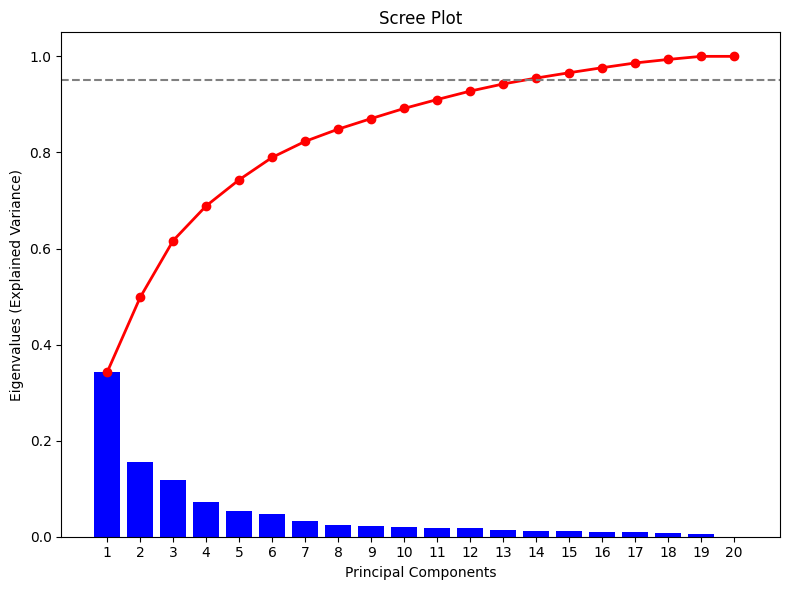

In [9]:
# calculate the cumulative explained variance
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# draw figure
fig, axes = plt.subplots(figsize=(8, 6))

# principal component variances
axes.bar(range(1, len(pca.explained_variance_ratio_)+1), 
             pca.explained_variance_ratio_, color='blue')
axes.set_xticks(range(1, len(pca.explained_variance_ratio_)+1))
axes.plot(range(1, len(pca.explained_variance_ratio_)+1), 
             np.cumsum(pca.explained_variance_ratio_), 'o-', linewidth=2, color='red')
axes.axhline(y=0.95, color='gray', linestyle='--')
axes.set_title('Scree Plot')
axes.set_xlabel('Principal Components')
axes.set_ylabel('Eigenvalues (Explained Variance)')
axes.grid(False)

# cumulative explained variance
plt.tight_layout()
plt.show()